# TUSZ v2.0.6 — first look at a seizure recording

Temple University Hospital **Seizure Corpus** (TUSZ), dev split. This notebook inspects a single
recording sampled from the corpus and lays the groundwork for treating clinical EEG as a
multivariate time series (MTS) for SPI analysis.

**Sample:** patient `aaaaaqbt`, session `s001` (2013), montage `01_tcp_ar`, file `t000`.
- 30 raw `EEG *-REF` channels @ **250 Hz**, **1203 s** (~20 min).
- Annotations: `.csv_bi` (term-level `seiz`/`bckg`) and `.csv` (per-channel, seizure *type*).
- This file: **three generalized seizures** (`gnsz`) at 191–248 s, 603–650 s, 980–1038 s.

**Montage matters.** TUSZ annotations are defined on the bipolar **TCP-AR "double-banana"**
montage (`FP1-F7`, `F7-T3`, …), *not* the raw referential channels. We reconstruct the exact
22 bipolar derivations from Temple's `01_tcp_ar_montage.txt` so signal and labels align.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram
import mne

mne.set_log_level("ERROR")

# --- locate project root (walk up for the sample dir) ---
ROOT = Path.cwd()
while not (ROOT / "data" / "tuh" / "tusz_sample").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SAMPLE = ROOT / "data" / "tuh" / "tusz_sample"

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.plot_style import apply_plot_style
apply_plot_style()
plt.rcParams["text.usetex"] = False  # channel/id strings contain '_' and '-'

REC = SAMPLE / "aaaaaqbt/s001_2013/01_tcp_ar/aaaaaqbt_s001_t000"
MONTAGE_FILE = SAMPLE / "DOCS" / "01_tcp_ar_montage.txt"
print("root:", ROOT)
print("edf :", REC.with_suffix(".edf").relative_to(ROOT))

root: /Users/wedi0306/Code/mts-spi-study-cluster
edf : data/tuh/tusz_sample/aaaaaqbt/s001_2013/01_tcp_ar/aaaaaqbt_s001_t000.edf


In [2]:
def parse_montage(path):
    """Return list of (label, chan_A, chan_B) from a TUH montage file."""
    pairs = []
    for line in Path(path).read_text().splitlines():
        m = re.match(r"\s*montage\s*=\s*\d+,\s*([^:]+):\s*(.+?)\s*--\s*(.+?)\s*$", line)
        if m:
            pairs.append((m.group(1).strip(), m.group(2).strip(), m.group(3).strip()))
    return pairs


def parse_annotation(path):
    """Return (meta dict, DataFrame) for a TUSZ .csv / .csv_bi label file."""
    meta = {}
    for line in Path(path).read_text().splitlines():
        if line.startswith("#") and "=" in line:
            k, v = line[1:].split("=", 1)
            meta[k.strip()] = v.strip()
        elif not line.startswith("#"):
            break
    df = pd.read_csv(path, comment="#")
    return meta, df


pairs = parse_montage(MONTAGE_FILE)
print(f"{len(pairs)} bipolar derivations:")
print(", ".join(lbl for lbl, _, _ in pairs))

22 bipolar derivations:
FP1-F7, F7-T3, T3-T5, T5-O1, FP2-F8, F8-T4, T4-T6, T6-O2, A1-T3, T3-C3, C3-CZ, CZ-C4, C4-T4, T4-A2, FP1-F3, F3-C3, C3-P3, P3-O1, FP2-F4, F4-C4, C4-P4, P4-O2


In [3]:
# --- load EDF and build the bipolar TCP-AR montage ---
raw = mne.io.read_raw_edf(REC.with_suffix(".edf"), preload=True)
sf = raw.info["sfreq"]
ref = raw.get_data()  # (n_chan, n_times), volts
idx = {name: i for i, name in enumerate(raw.ch_names)}

labels = [lbl for lbl, _, _ in pairs]
bip = np.vstack([ref[idx[a]] - ref[idx[b]] for _, a, b in pairs]) * 1e6  # -> microvolts
t = np.arange(bip.shape[1]) / sf
print(f"bipolar signal: {bip.shape[0]} ch x {bip.shape[1]} samples "
      f"({t[-1]:.0f} s @ {sf:.0f} Hz)")

# --- seizure events (term-level, from .csv_bi) ---
meta_bi, ann_bi = parse_annotation(REC.with_suffix(".csv_bi"))
seiz = ann_bi[ann_bi.label == "seiz"][["start_time", "stop_time"]].to_numpy()
# per-channel type (from .csv): all derivations share the same gnsz type here
_, ann = parse_annotation(REC.with_suffix(".csv"))
sz_type = ann[ann.label != "bckg"].label.unique()
print(f"{len(seiz)} seizure events, type(s): {list(sz_type)}")
pd.DataFrame(seiz, columns=["start_s", "stop_s"]).assign(
    dur_s=lambda d: (d.stop_s - d.start_s).round(1))

bipolar signal: 22 ch x 300750 samples (1203 s @ 250 Hz)
3 seizure events, type(s): ['gnsz']


,start_s,stop_s,dur_s
0,191.0030,248.0510,57.0
1,603.0124,649.9004,46.9
2,980.0130,1038.1043,58.1


## 1. Whole-recording overview

All 22 bipolar channels, stacked. Red spans mark annotated seizures. Decimated for display.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

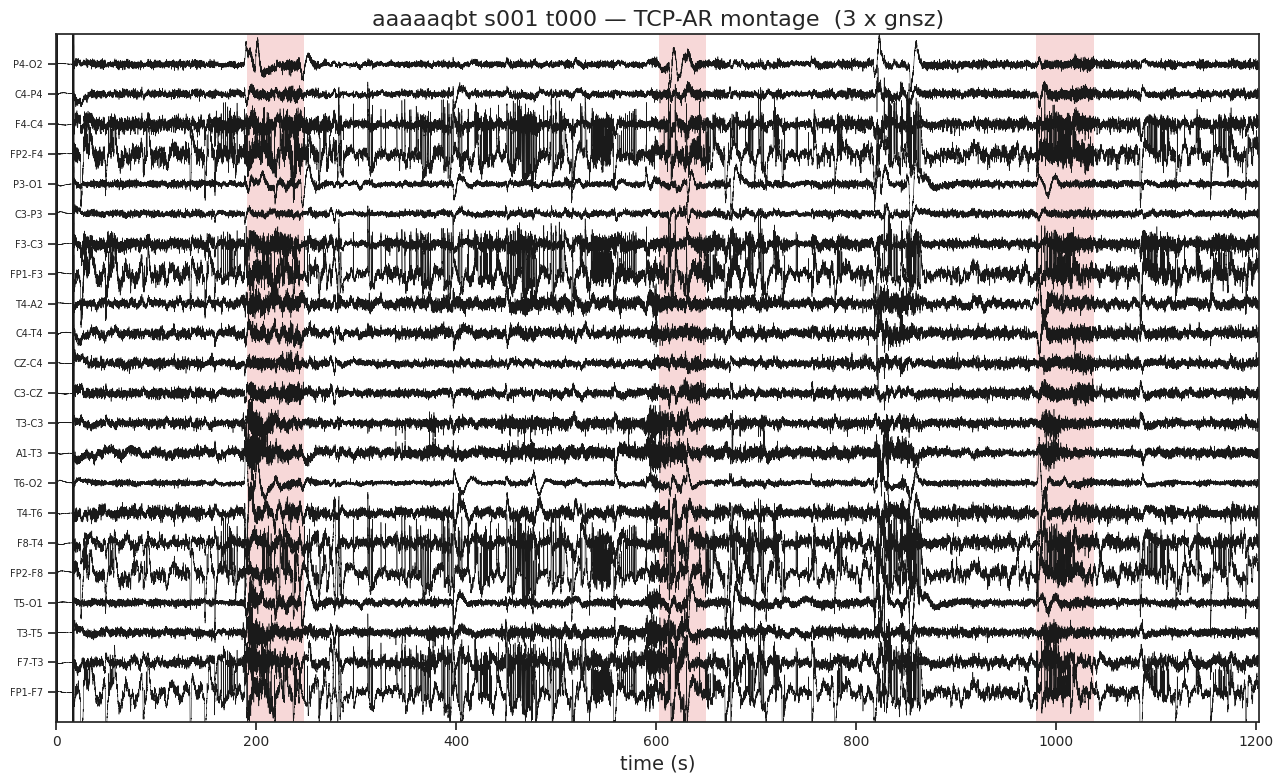

In [4]:
dec = int(sf / 50)  # ~50 Hz for the overview
td, bd = t[::dec], bip[:, ::dec]
spacing = 2.5 * np.percentile(np.abs(bip), 95)

fig, ax = plt.subplots(figsize=(13, 8))
for i, lbl in enumerate(labels):
    ax.plot(td, bd[i] + i * spacing, lw=0.4, color="k")
for s0, s1 in seiz:
    ax.axvspan(s0, s1, color="tab:red", alpha=0.18, lw=0)
ax.set_yticks([i * spacing for i in range(len(labels))])
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("time (s)")
ax.set_xlim(0, t[-1])
ax.set_ylim(-spacing, len(labels) * spacing)
ax.set_title(f"aaaaaqbt s001 t000 — TCP-AR montage  ({len(seiz)} x {sz_type[0]})")
ax.margins(x=0)
plt.tight_layout()
plt.show()

## 2. Seizure onset, full resolution

Zoom on the first event (± 15 s). Rhythmic, high-amplitude discharge emerges across channels.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

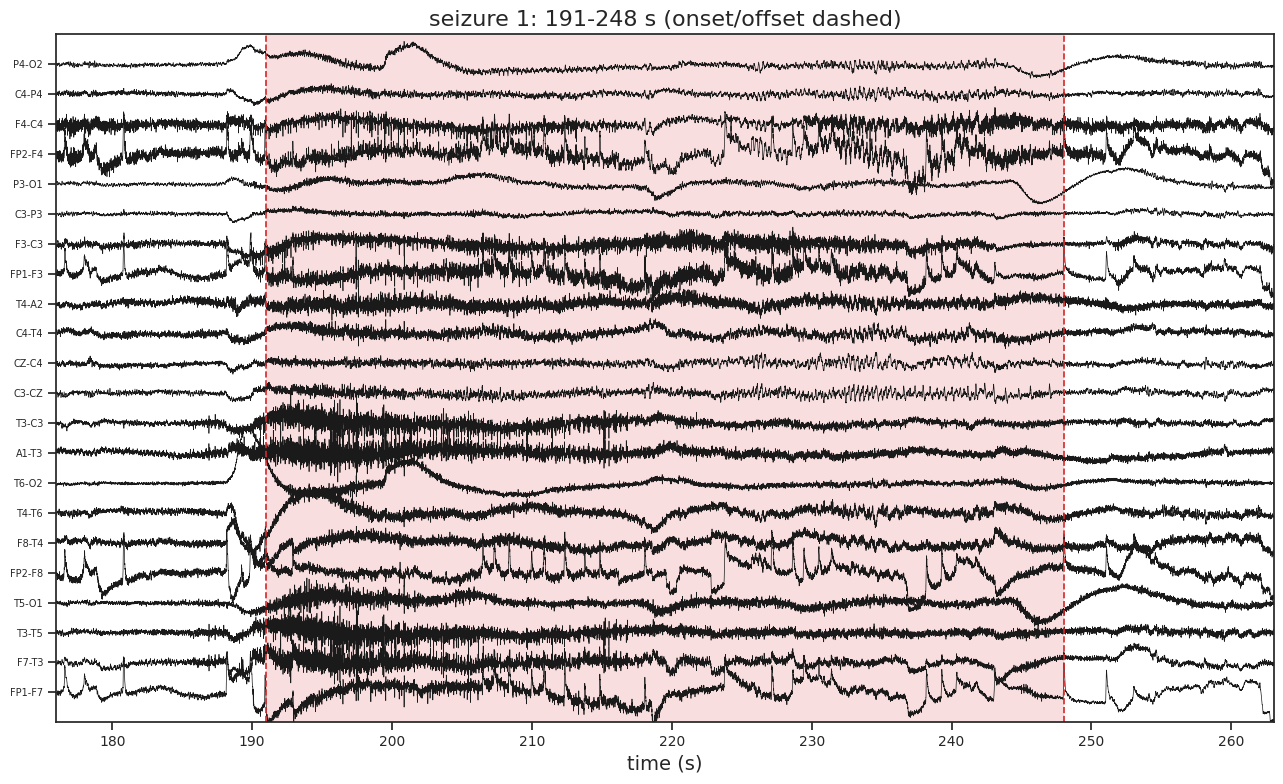

In [5]:
s0, s1 = seiz[0]
w0, w1 = s0 - 15, s1 + 15
m = (t >= w0) & (t <= w1)
sp = 2.5 * np.percentile(np.abs(bip[:, m]), 95)

fig, ax = plt.subplots(figsize=(13, 8))
for i, lbl in enumerate(labels):
    ax.plot(t[m], bip[i, m] + i * sp, lw=0.5, color="k")
ax.axvspan(s0, s1, color="tab:red", alpha=0.15, lw=0)
ax.axvline(s0, color="tab:red", lw=1.2, ls="--")
ax.axvline(s1, color="tab:red", lw=1.2, ls="--")
ax.set_yticks([i * sp for i in range(len(labels))])
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("time (s)")
ax.set_xlim(w0, w1)
ax.set_ylim(-sp, len(labels) * sp)
ax.set_title(f"seizure 1: {s0:.0f}-{s1:.0f} s (onset/offset dashed)")
ax.margins(x=0)
plt.tight_layout()
plt.show()

## 3. Spectral contrast: background vs seizure

Welch PSD averaged across the 22 channels, for a clean background window vs a within-seizure
window. Seizure activity concentrates power in the low bands (rhythmic delta/theta).

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

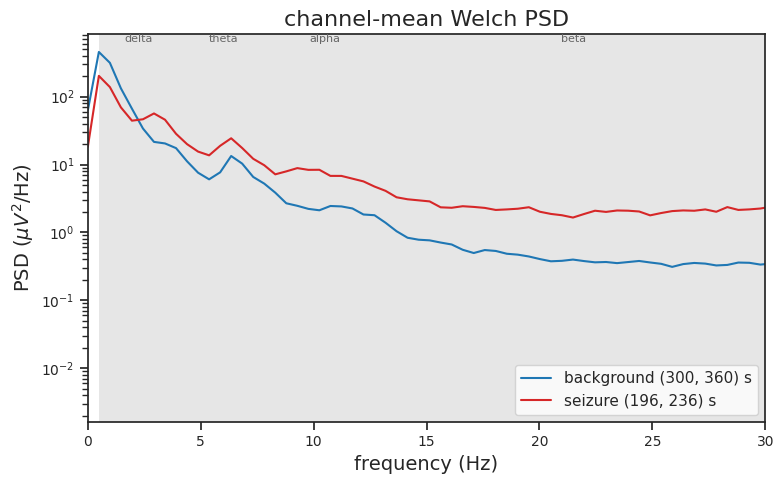

In [6]:
def band_psd(win):
    a, b = int(win[0] * sf), int(win[1] * sf)
    f, P = welch(bip[:, a:b], fs=sf, nperseg=512, axis=1)
    return f, P.mean(0)

bg_win = (300, 360)            # clear of all three seizures
sz_win = (s0 + 5, s0 + 45)     # inside seizure 1
f, P_bg = band_psd(bg_win)
_, P_sz = band_psd(sz_win)

bands = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 13), "beta": (13, 30)}
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(f, P_bg, color="tab:blue", label=f"background {bg_win} s")
ax.semilogy(f, P_sz, color="tab:red", label=f"seizure {tuple(round(x) for x in sz_win)} s")
for (lo, hi) in bands.values():
    ax.axvspan(lo, hi, color="0.9", lw=0, zorder=0)
for name, (lo, hi) in bands.items():
    ax.text((lo + hi) / 2, ax.get_ylim()[1], name, ha="center", va="top", fontsize=8, color="0.4")
ax.set_xlim(0, 30)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"PSD ($\mu V^2$/Hz)")
ax.set_title("channel-mean Welch PSD")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Spectrogram of one channel

Time–frequency view of a temporal channel (`T5-O1`) across the full recording. Seizure spans
(red) coincide with broadband low-frequency power increases.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

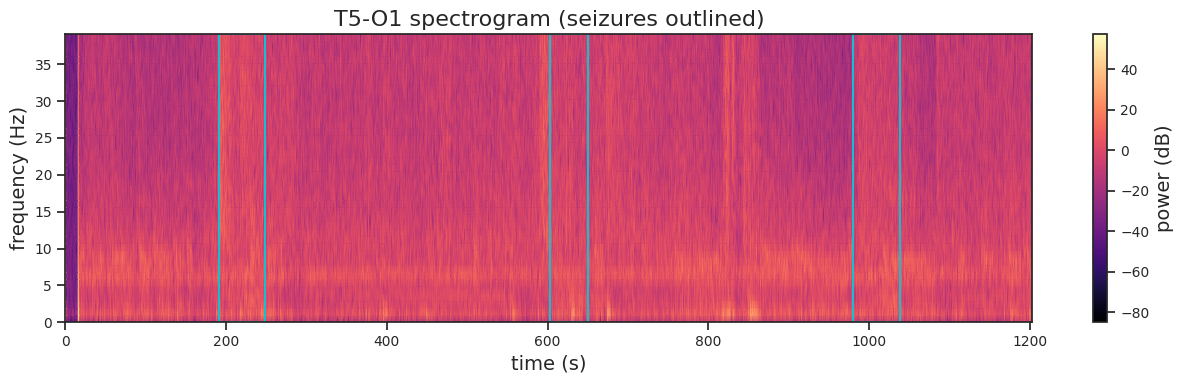

In [7]:
ch = "T5-O1"
sig = bip[labels.index(ch)]
fsp, tsp, Sxx = spectrogram(sig, fs=sf, nperseg=256, noverlap=192)
band = fsp <= 40

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.pcolormesh(tsp, fsp[band], 10 * np.log10(Sxx[band] + 1e-12),
                   shading="gouraud", cmap="magma")
for s0_, s1_ in seiz:
    ax.axvspan(s0_, s1_, ec="tab:cyan", fc="none", lw=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("frequency (Hz)")
ax.set_title(f"{ch} spectrogram (seizures outlined)")
ax.set_xlim(0, t[-1])
fig.colorbar(im, ax=ax, label="power (dB)")
plt.tight_layout()
plt.show()

## Notes & next steps

- Each bipolar derivation is one variable of a 22-D MTS; a seizure is a **regime change** — the
  cross-channel dependency structure (what SPIs quantify) should shift between background and ictal
  segments. This sample is a natural testbed for that.
- Old TUH nomenclature: `T3/T4/T5/T6` = modern `T7/T8/P7/P8`; needed before any 10–20 topomap.
- `.csv` carries the seizure **type** (`gnsz`, `fnsz`, `cpsz`, …); `.csv_bi` collapses to
  `seiz`/`bckg`. See `DOCS/seizures_types_v02.xlsx`.
- **Scaling up:** bulk TUSZ belongs on cluster scratch (Gadi/Physics), not this laptop — the same
  parse/montage code drives batch feature extraction there.
